<a href="https://colab.research.google.com/github/ashoktamang002/Foundation-of-Data-Science/blob/main/Assessment%202%20Solution/Analytic%20Task%203/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FIFA World Cup 2026 Fouls and Tackles Analysis

This notebook answers the analytical question:

**Do teams that commit more fouls per match have a significantly different average number of tackles per match than teams that commit fewer fouls?**

The workflow is deliberately simple and beginner-friendly:

**raw data -> cleaning -> final dataset -> analysis**

## 1. Analytical Question

**Research question:** Do teams that commit more fouls per match have a significantly different average number of tackles per match than teams that commit fewer fouls?

**Null hypothesis (H0):** There is no significant difference in average tackles per match between teams with higher and lower foul rates.

**Alternative hypothesis (H1):** There is a significant difference in average tackles per match between teams with higher and lower foul rates.

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## 2. Data Collection

The data was manually collected into an Excel workbook from The Stats Don't Lie (TSDL) / the source notes in the workbook.

Main TSDL page: https://www.thestatsdontlie.com/football/world-cup-2026/

**Important note:** The workbook uses `Tackles_Won_Total`, so this analysis is based on tackles won per match.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving FIFA_World_Cup_2026_Fouls_Tackles.xlsx to FIFA_World_Cup_2026_Fouls_Tackles.xlsx


In [4]:
file_name = "FIFA_World_Cup_2026_Fouls_Tackles.xlsx"

## 3. Data Wrangling

In this section, the raw Excel data is loaded, checked, cleaned, and changed into a final dataset containing only the variables needed for the research question.

In [5]:
# Load the raw data sheet from the Excel file.
# This sheet contains the original team-level totals before analysis columns are created.
file_name = 'FIFA_World_Cup_2026_Fouls_Tackles.xlsx'
raw_data = pd.read_excel(file_name, sheet_name="Raw_Data")

# Display the first five rows so we can check that the data loaded correctly.
raw_data.head()

,Team,Games_Played,Fouls_Total,Tackles_Won_Total
0,Algeria,4,29,44
1,Argentina,8,113,93
2,Australia,4,46,34
3,Austria,4,47,29
4,Belgium,6,78,47


In [6]:
raw_data.columns

Index(['Team', 'Games_Played', 'Fouls_Total', 'Tackles_Won_Total'], dtype='object')

In [7]:
fouls = raw_data[["Team", "Games_Played", "Fouls_Total"]]
tackles = raw_data[["Team", "Tackles_Won_Total"]]

tackles = tackles.rename(columns={"Tackles_Won_Total": "Tackles_Total"})

df = fouls.merge(tackles, on="Team", how="inner")

df["Fouls_Per_Match"] = df["Fouls_Total"] / df["Games_Played"]

df["Tackles_Per_Match"] = df["Tackles_Total"] / df["Games_Played"]

df = df[["Team", "Fouls_Per_Match", "Tackles_Per_Match"]]

# Show the cleaned dataset before checking for missing values.
df.head()

,Team,Fouls_Per_Match,Tackles_Per_Match
0,Algeria,7.250,11.000000
1,Argentina,14.125,11.625000
2,Australia,11.500,8.500000
3,Austria,11.750,7.250000
4,Belgium,13.000,7.833333


In [8]:
# Check the structure of the cleaned dataset.
# This helps confirm the number of rows, column names, and data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Team               48 non-null     object 
 1   Fouls_Per_Match    48 non-null     float64
 2   Tackles_Per_Match  48 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.3+ KB


In [9]:
# Check for missing values in each column.
# Missing values could affect the mean, confidence interval, and t-test.
df.isnull().sum()

,0
Team,0
Fouls_Per_Match,0
Tackles_Per_Match,0


In [10]:
df = df.dropna()

# Check missing values again to confirm that the cleaned dataset is complete.
df.isnull().sum()

,0
Team,0
Fouls_Per_Match,0
Tackles_Per_Match,0


In [11]:
# Show the cleaned final dataset.
df.head()

,Team,Fouls_Per_Match,Tackles_Per_Match
0,Algeria,7.250,11.000000
1,Argentina,14.125,11.625000
2,Australia,11.500,8.500000
3,Austria,11.750,7.250000
4,Belgium,13.000,7.833333


## 4. Data Preparation and Sampling

**Population:** The target population is teams in the FIFA World Cup 2026 team-level dataset relevant to the research question.

**Sample:** The sample is the set of teams manually collected in this workbook. In this file there are 48 teams.

**Sampling approach:** This is not a random sample. It is an available dataset of teams collected from the source. If the workbook contains all available teams from the source, then it can be described as analysing the available population from that source. The confidence interval and t-test are still useful for practising inference, but the results should be interpreted in relation to the collected dataset.

The median fouls per match is used as the cutoff because it splits the teams into two similarly sized groups and is less affected by very high or very low foul values than the mean.

In [12]:
# Calculate the median fouls per match.
median_fouls = df["Fouls_Per_Match"].median()

# Create a new group column using the median as the cutoff.
df["Foul_Group"] = df["Fouls_Per_Match"].apply(lambda x: 1 if x > median_fouls else 0)

# Show the median fouls per match.
median_fouls

11.375

In [13]:
# Show the final dataset with the foul group column added.
df.head()

,Team,Fouls_Per_Match,Tackles_Per_Match,Foul_Group
0,Algeria,7.250,11.000000,0
1,Argentina,14.125,11.625000,1
2,Australia,11.500,8.500000,1
3,Austria,11.750,7.250000,1
4,Belgium,13.000,7.833333,1


## 5. Descriptive Statistics

The mean shows the average tackles per match. The median shows the middle value. The standard deviation shows how spread out the tackles per match values are within each group.

In [14]:
df[["Fouls_Per_Match", "Tackles_Per_Match"]].describe()

,Fouls_Per_Match,Tackles_Per_Match
count,48.000000,48.000000
mean,11.538021,9.695312
std,2.356692,2.246191
min,6.750000,6.333333
25%,10.181250,8.000000
50%,11.375000,9.416667
75%,13.050000,11.187500
max,18.333333,17.600000


In [15]:
# Calculate descriptive statistics for tackles per match by foul group.
group_stats = df.groupby("Foul_Group")["Tackles_Per_Match"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

# Display the grouped descriptive statistics.
group_stats

,count,mean,median,std,min,max
Foul_Group,,,,,,
0,24,9.582639,9.562500,1.860817,6.750000,13.0
1,24,9.807986,9.291667,2.611700,6.333333,17.6


In [16]:
# Separate the tackles data into two groups for the confidence intervals and t-test.
high_fouls = df[df["Foul_Group"] == 1]["Tackles_Per_Match"]
low_fouls = df[df["Foul_Group"] == 0]["Tackles_Per_Match"]

# Calculate each group mean so the output is easy to interpret.
high_mean = high_fouls.mean()
low_mean = low_fouls.mean()

# Print the means clearly.
print("Higher-foul teams mean tackles per match:", high_mean)
print("Lower-foul teams mean tackles per match:", low_mean)

Higher-foul teams mean tackles per match: 9.807986111111111
Lower-foul teams mean tackles per match: 9.582638888888889


## 6. 95% Confidence Interval

Conceptual formula:

**confidence interval = sample mean +/- t critical value * standard error**

**standard error = sample standard deviation / square root of sample size**

A 95% confidence interval gives a likely range for the true mean tackles per match for each foul group, based on the collected data.

In [17]:
# Calculate the information needed for the higher-foul confidence interval.
high_n = high_fouls.count()
high_std = high_fouls.std()
high_se = high_std / np.sqrt(high_n)
high_t_critical = stats.t.ppf(0.975, df=high_n - 1)
high_margin_error = high_t_critical * high_se
high_ci_lower = high_mean - high_margin_error
high_ci_upper = high_mean + high_margin_error

# Calculate the information needed for the lower-foul confidence interval.
low_n = low_fouls.count()
low_std = low_fouls.std()
low_se = low_std / np.sqrt(low_n)
low_t_critical = stats.t.ppf(0.975, df=low_n - 1)
low_margin_error = low_t_critical * low_se
low_ci_lower = low_mean - low_margin_error
low_ci_upper = low_mean + low_margin_error

# Print the confidence interval results clearly.
print("Higher-foul teams:")
print("Mean tackles per match:", high_mean)
print("95% confidence interval:", high_ci_lower, "to", high_ci_upper)

print("\nLower-foul teams:")
print("Mean tackles per match:", low_mean)
print("95% confidence interval:", low_ci_lower, "to", low_ci_upper)

Higher-foul teams:
Mean tackles per match: 9.807986111111111
95% confidence interval: 8.705162064924039 to 10.910810157298183

Lower-foul teams:
Mean tackles per match: 9.582638888888889
95% confidence interval: 8.79688495501563 to 10.368392822762148


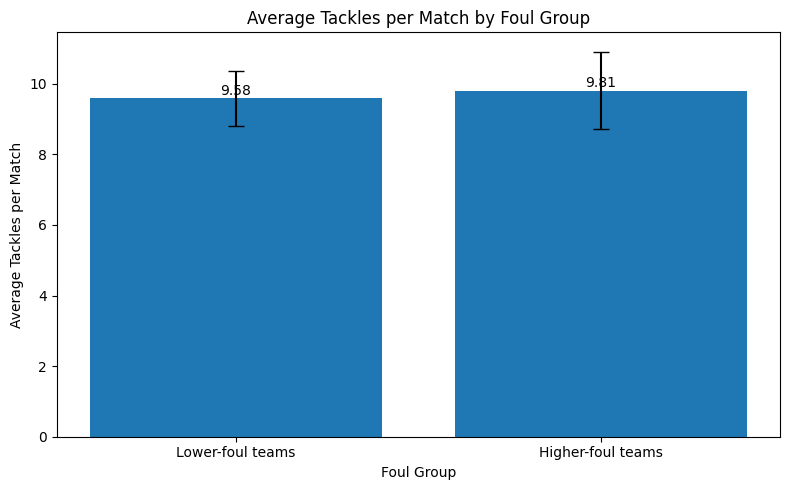

In [18]:
# Data for the graph
groups = ["Lower-foul teams", "Higher-foul teams"]
means = [low_mean, high_mean]

# Calculate the confidence interval error sizes
lower_errors = [
    low_mean - low_ci_lower,
    high_mean - high_ci_lower
]

upper_errors = [
    low_ci_upper - low_mean,
    high_ci_upper - high_mean
]

# Combine lower and upper errors for matplotlib
errors = np.array([lower_errors, upper_errors])

# Create the bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    groups,
    means,
    yerr=errors,
    capsize=6
)

# Add labels and title
plt.title("Average Tackles per Match by Foul Group")
plt.xlabel("Foul Group")
plt.ylabel("Average Tackles per Match")

# Add the exact mean values above each bar
for i, mean in enumerate(means):
    plt.text(
        i,
        mean + 0.1,
        f"{mean:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 7. Two-Sample t-Test

This analysis uses Welch's independent two-sample t-test because it compares the average tackles per match of two separate groups and does not assume equal variances.

**H0:** There is no significant difference in average tackles per match between teams with higher and lower foul rates.

**H1:** There is a significant difference in average tackles per match between teams with higher and lower foul rates.

In [19]:
# Perform Welch's independent two-sample t-test.
# Welch's t-test is used because it does not assume the two groups have equal variances.
t_statistic, p_value = stats.ttest_ind(high_fouls, low_fouls, equal_var=False)

# Set the significance level.
alpha = 0.05

# Print the t-test results.
print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 0.34425872582585987
p-value: 0.7323873269738463


## 8. Interpretation

The p-value is compared with alpha = 0.05.

If p < 0.05, reject H0.

If p >= 0.05, fail to reject H0.

In [20]:
# Use a simple if/else statement to decide whether the result is statistically significant.
if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference in average tackles per match")
    print("between higher-foul and lower-foul teams at alpha = 0.05.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is not enough evidence of a statistically significant difference")
    print("in average tackles per match between higher-foul and lower-foul teams at alpha = 0.05.")

Decision: Fail to reject the null hypothesis.
Conclusion: There is not enough evidence of a statistically significant difference
in average tackles per match between higher-foul and lower-foul teams at alpha = 0.05.


## 9. Final Conclusion

This final cell prints the conclusion using the values calculated from the dataset.

In [21]:
# Print a short final conclusion using the actual calculated values.
if high_mean > low_mean:
    print("Higher-foul teams had the higher average tackles per match.")
else:
    print("Lower-foul teams had the higher average tackles per match.")

print("Higher-foul teams mean tackles per match:", round(high_mean, 2))
print("Higher-foul teams 95% CI:", round(high_ci_lower, 2), "to", round(high_ci_upper, 2))
print("Lower-foul teams mean tackles per match:", round(low_mean, 2))
print("Lower-foul teams 95% CI:", round(low_ci_lower, 2), "to", round(low_ci_upper, 2))
print("t-test p-value:", round(p_value, 4))

if p_value < alpha:
    print("Because the p-value is below 0.05, the difference is statistically significant.")
else:
    print("Because the p-value is 0.05 or higher, the difference is not statistically significant.")

Higher-foul teams had the higher average tackles per match.
Higher-foul teams mean tackles per match: 9.81
Higher-foul teams 95% CI: 8.71 to 10.91
Lower-foul teams mean tackles per match: 9.58
Lower-foul teams 95% CI: 8.8 to 10.37
t-test p-value: 0.7324
Because the p-value is 0.05 or higher, the difference is not statistically significant.
